# Weather Forecasting Analysis

## Introduction

Weather forecasting plays a crucial role in many aspects of everyday life, including transportation, agriculture, energy management, and public safety. Understanding the relationships between different meteorological variables can improve forecasting accuracy and provide valuable insights into weather patterns. The main objective of this project is to analyze historical weather data and investigate how atmospheric conditions influence apparent temperature. The study focuses on four key weather variables:

- Air Temperature
- Humidity
- Wind Speed
- Atmospheric Pressure

The project includes data cleaning, exploratory data analysis (EDA), statistical analysis, multiple linear regression, model evaluation, and weather forecasting techniques.

The entire analysis was performed using Python and its data science ecosystem, including Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, and Statsmodels.

# Project Objectives

The objectives of this project are:

- Explore the structure and quality of the dataset.
- Identify relationships between weather variables.
- Determine which variables have the greatest impact on apparent temperature.
- Build a multiple linear regression model.
- Evaluate model performance using statistical metrics.
- Visualize important relationships between variables.
- Develop a simple weather forecasting model.
- Present business and scientific conclusions based on the analysis.

# Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/weatherHistory.csv")

# Data Quality Assessment

In [3]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [4]:
df.shape

(96453, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 8.8 MB


In [6]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df.nunique()

Formatted Date              96429
Summary                        27
Precip Type                     2
Temperature (C)              7574
Apparent Temperature (C)     8984
Humidity                       90
Wind Speed (km/h)            2484
Wind Bearing (degrees)        360
Visibility (km)               949
Loud Cover                      1
Pressure (millibars)         4979
Daily Summary                 214
dtype: int64

## Observations

The dataset contains 96,453 observations describing historical weather conditions collected over several years.
Only 24 duplicate records were identified, indicating that duplicate observations are not a significant data quality issue.
Most variables are complete and contain values within expected ranges. Missing values are present only in the Precip Type feature, suggesting that limited preprocessing will be required before model development.
The dataset includes a combination of continuous meteorological measurements (temperature, humidity, pressure, wind speed and visibility) together with categorical weather descriptions, providing a suitable foundation for both exploratory analysis and predictive modeling.
Based on the initial assessment, the overall quality of the dataset is high and no major issues that would prevent further analysis were identified.

# Missing Values

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_percent = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent.round(2)
})

missing_table

,Missing Values,Percentage (%)
Precip Type,517,0.54
Formatted Date,0,0.00
Summary,0,0.00
Temperature (C),0,0.00
Apparent Temperature (C),0,0.00
Humidity,0,0.00
Wind Speed (km/h),0,0.00
Wind Bearing (degrees),0,0.00
Visibility (km),0,0.00
Loud Cover,0,0.00


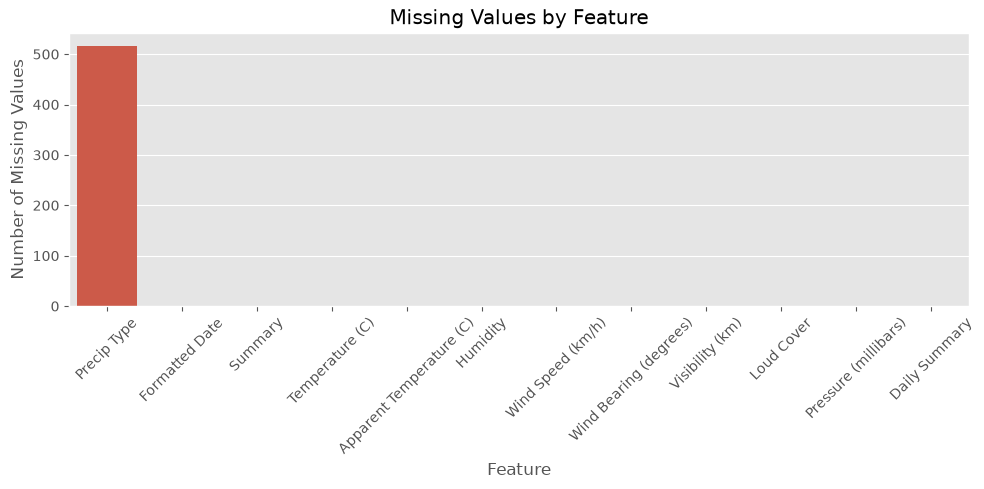

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_table.index,
    y=missing_table["Missing Values"]
)

plt.xticks(rotation=45)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")

plt.tight_layout()

plt.show()

## Observations

The dataset contains missing values in only one feature (**Precip Type**), whereas all other variables are complete. This indicates that missing data are unlikely to have a significant impact on the overall analysis. Depending on the modeling approach, the missing observations can either be removed or imputed without substantially affecting the dataset.

# Temperature Distribution

Air temperature is one of the key variables describing weather conditions. Examining its distribution helps identify seasonal patterns, variability, and potential outliers before developing predictive models.

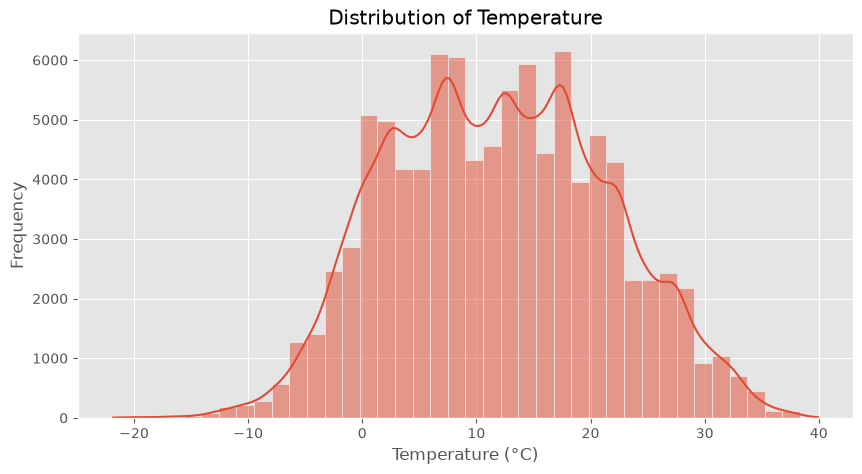

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Temperature (C)"],
    bins=40,
    kde=True
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

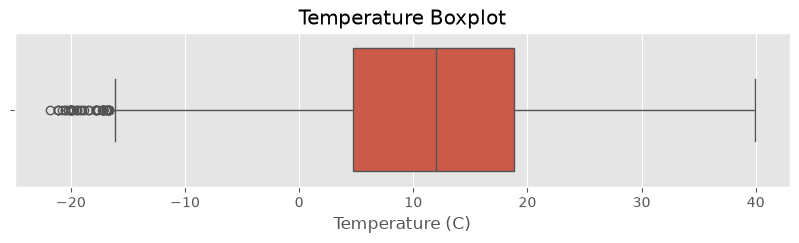

In [12]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Temperature (C)"]
)

plt.title("Temperature Boxplot")

plt.show()

In [13]:
df["Temperature (C)"].describe()

count    96453.000000
mean        11.932678
std          9.551546
min        -21.822222
25%          4.688889
50%         12.000000
75%         18.838889
max         39.905556
Name: Temperature (C), dtype: float64

## Observations

The temperature values cover a broad range, from below freezing to nearly 40°C.The histogram indicates that temperatures are distributed across different seasons rather than following a perfectly normal distribution.The boxplot suggests the presence of several extreme observations, although they appear realistic for long-term weather measurements rather than data errors.

# Humidity Distribution

Humidity is another important weather indicator that influences temperature, precipitation, and overall weather conditions.

This section explores the distribution of humidity values and identifies potential outliers.

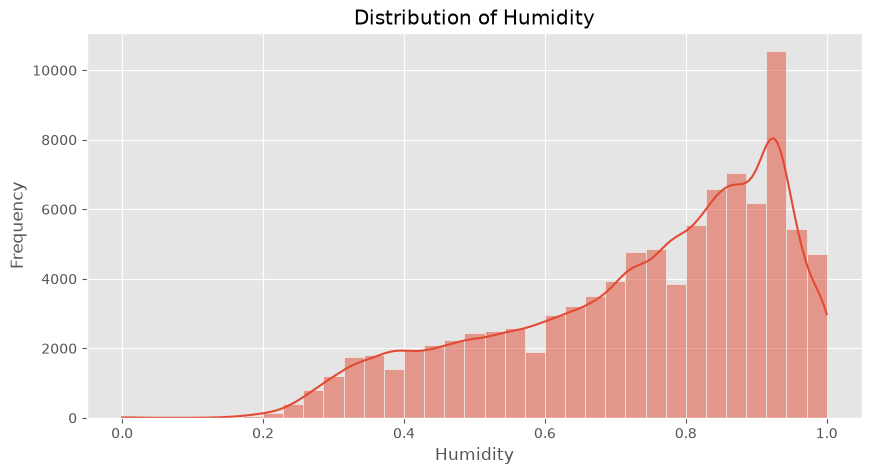

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Humidity"],
    bins=35,
    kde=True
)

plt.title("Distribution of Humidity")
plt.xlabel("Humidity")
plt.ylabel("Frequency")

plt.show()

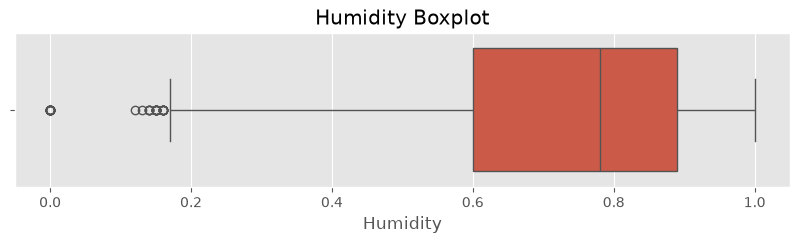

In [15]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Humidity"]
)

plt.title("Humidity Boxplot")

plt.show()

In [16]:
df["Humidity"].describe()

count    96453.000000
mean         0.734899
std          0.195473
min          0.000000
25%          0.600000
50%          0.780000
75%          0.890000
max          1.000000
Name: Humidity, dtype: float64

## Observations

Humidity values are concentrated between approximately 0.6 and 1.0, indicating that most observations were recorded under relatively humid conditions.The distribution is left-skewed, with relatively few observations at very low humidity levels. No unrealistic values are visible, suggesting good data quality for this variable.

# Wind Speed Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df["Wind Speed (km/h)"],
    bins=40,
    kde=True
)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.show()Wind speed plays an important role in weather conditions and influences temperature perception, precipitation, and atmospheric pressure. This section examines the distribution of wind speed measurements and identifies possible extreme observations.

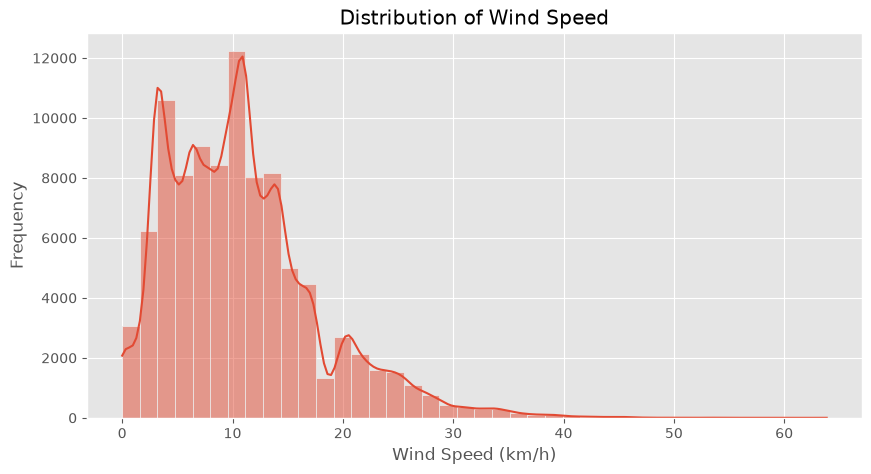

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Wind Speed (km/h)"],
    bins=40,
    kde=True
)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.show()

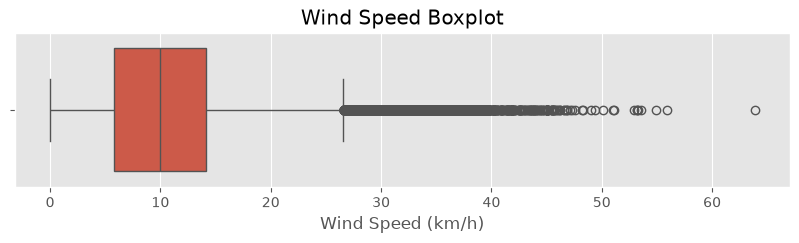

In [18]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Wind Speed (km/h)"]
)

plt.title("Wind Speed Boxplot")

plt.show()

In [19]:
df["Wind Speed (km/h)"].describe()

count    96453.000000
mean        10.810640
std          6.913571
min          0.000000
25%          5.828200
50%          9.965900
75%         14.135800
max         63.852600
Name: Wind Speed (km/h), dtype: float64

## Observations

Wind speed values are concentrated at relatively low to moderate levels, while higher wind speeds occur less frequently. The histogram shows a positively skewed distribution with a small number of stronger wind events. The boxplot identifies several high-value observations; however, these appear to represent genuine weather conditions rather than measurement errors. Overall, the variable provides useful information for future predictive modeling.

# Pressure Distribution

Atmospheric pressure is a key indicator of changing weather conditions and is closely related to the movement of air masses. This section examines the variability of atmospheric pressure, identifies potential anomalies, and evaluates whether the observed values are consistent with realistic weather measurements.

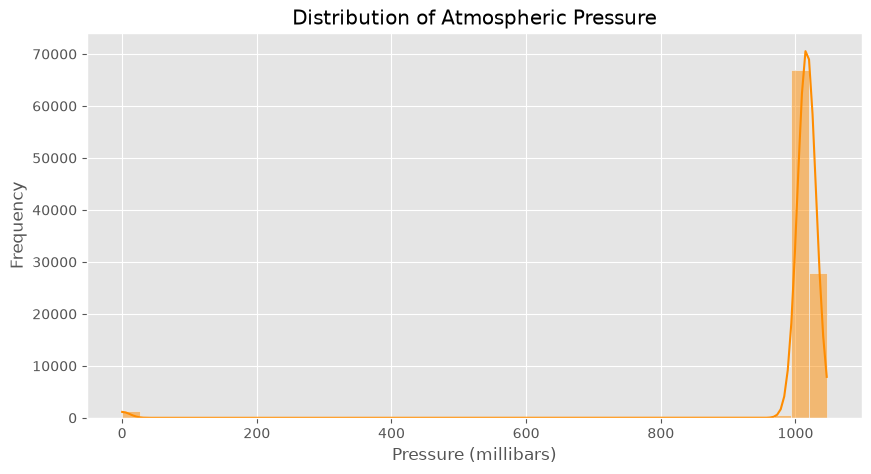

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Pressure (millibars)"],
    bins=40,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Atmospheric Pressure")
plt.xlabel("Pressure (millibars)")
plt.ylabel("Frequency")

plt.show()

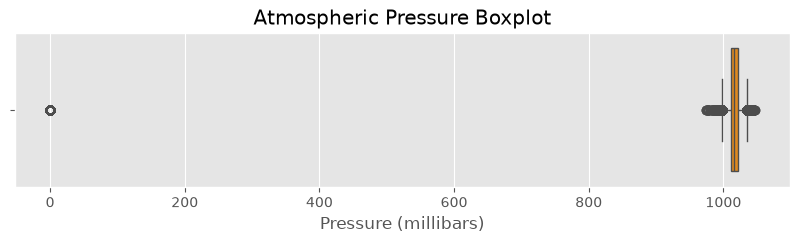

In [21]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Pressure (millibars)"],
    color="darkorange"
)

plt.title("Atmospheric Pressure Boxplot")

plt.show()

In [22]:
df["Pressure (millibars)"].describe()

count    96453.000000
mean      1003.235956
std        116.969906
min          0.000000
25%       1011.900000
50%       1016.450000
75%       1021.090000
max       1046.380000
Name: Pressure (millibars), dtype: float64

In [23]:
(df["Pressure (millibars)"] == 0).sum()

np.int64(1288)

## Observations

Atmospheric pressure values are concentrated within a relatively narrow range, indicating stable weather conditions during most observations. The distribution is close to normal, with only a limited number of unusually low or high measurements. These values most likely correspond to periods of rapidly changing weather rather than data quality issues.If pressure values equal to zero are present, they should be treated as missing or invalid observations before predictive modeling, since such measurements are not physically meaningful.

# Visibility Distribution

Visibility is an important indicator of atmospheric conditions and directly affects transportation safety and weather forecasting.This section investigates the distribution of visibility measurements and evaluates whether the recorded values appear consistent across the dataset.

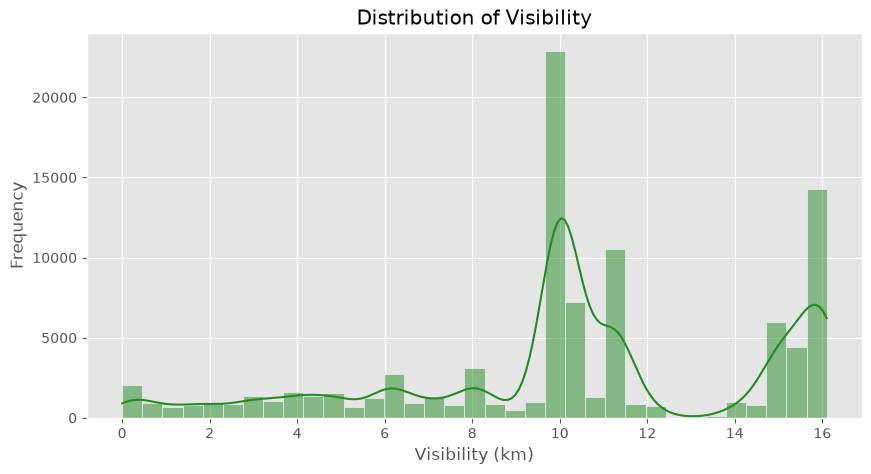

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Visibility (km)"],
    bins=35,
    kde=True,
    color="forestgreen"
)

plt.title("Distribution of Visibility")
plt.xlabel("Visibility (km)")
plt.ylabel("Frequency")

plt.show()

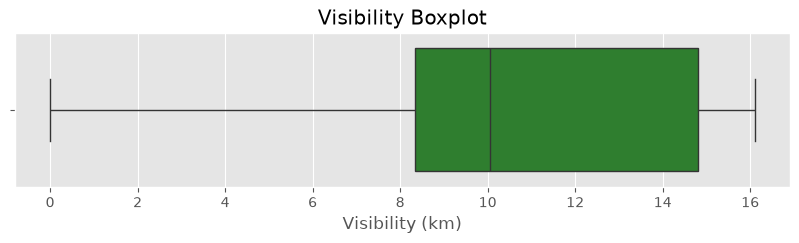

In [25]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Visibility (km)"],
    color="forestgreen"
)

plt.title("Visibility Boxplot")

plt.show()

In [26]:
df["Visibility (km)"].describe()

count    96453.000000
mean        10.347325
std          4.192123
min          0.000000
25%          8.339800
50%         10.046400
75%         14.812000
max         16.100000
Name: Visibility (km), dtype: float64

## Observations

Most visibility measurements are concentrated at relatively high values, suggesting that clear weather conditions dominate the dataset. Lower visibility events occur much less frequently and most likely correspond to rain, fog, or other adverse weather conditions. Although several observations appear as statistical outliers, they remain plausible for real-world meteorological measurements.Overall, visibility represents a reliable feature that may contribute useful information in predictive weather models.

# Correlation Analysis

Understanding relationships between variables is a key step in exploratory data analysis. Correlation analysis helps identify dependencies between weather measurements, detect redundant features, and determine which variables may be the most informative for predictive modeling.

In [27]:
numerical_df = (
    df.select_dtypes(include="number")
      .loc[:, df.select_dtypes(include="number").nunique() > 1]
)

numerical_df.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


In [28]:
corr_matrix = numerical_df.corr()

corr_matrix

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
Temperature (C),1.000000,0.992629,-0.632255,0.008957,0.029988,0.392847,-0.005447
Apparent Temperature (C),0.992629,1.000000,-0.602571,-0.056650,0.029031,0.381718,-0.000219
Humidity,-0.632255,-0.602571,1.000000,-0.224951,0.000735,-0.369173,0.005454
Wind Speed (km/h),0.008957,-0.056650,-0.224951,1.000000,0.103822,0.100749,-0.049263
Wind Bearing (degrees),0.029988,0.029031,0.000735,0.103822,1.000000,0.047594,-0.011651
Visibility (km),0.392847,0.381718,-0.369173,0.100749,0.047594,1.000000,0.059818
Pressure (millibars),-0.005447,-0.000219,0.005454,-0.049263,-0.011651,0.059818,1.000000


In [29]:
temperature_corr = (
    corr_matrix["Temperature (C)"]
    .sort_values(ascending=False)
)

temperature_corr

Temperature (C)             1.000000
Apparent Temperature (C)    0.992629
Visibility (km)             0.392847
Wind Bearing (degrees)      0.029988
Wind Speed (km/h)           0.008957
Pressure (millibars)       -0.005447
Humidity                   -0.632255
Name: Temperature (C), dtype: float64

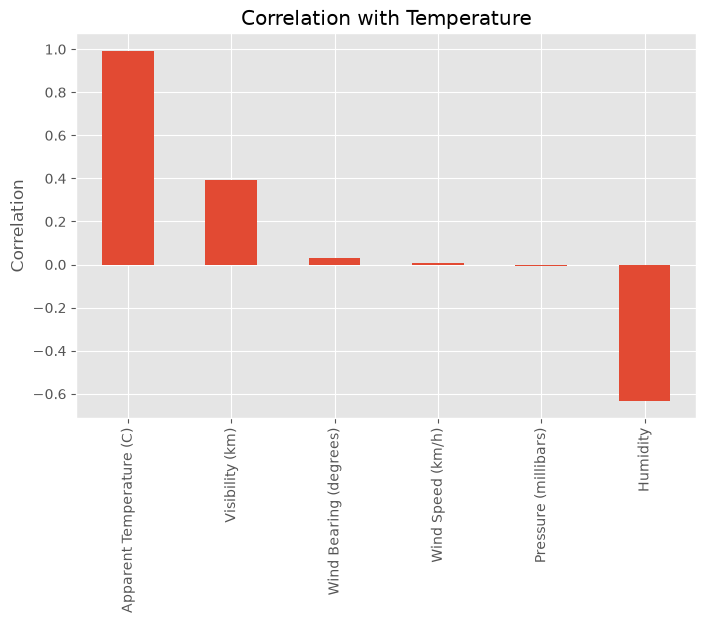

In [30]:
plt.figure(figsize=(8,5))

temperature_corr.drop("Temperature (C)").plot(
    kind="bar"
)

plt.title("Correlation with Temperature")
plt.ylabel("Correlation")
plt.show()

## Observations

The correlation matrix highlights several meaningful relationships between the variables.Temperature and Apparent Temperature exhibit an almost perfect positive correlation (r ≈ 0.99), indicating that both variables describe nearly the same physical phenomenon. Because of this, including both variables in the same predictive model may introduce multicollinearity.Humidity is moderately negatively correlated with Temperature (r ≈ -0.63), suggesting that warmer conditions are generally associated with lower relative humidity.Visibility has a moderate positive correlation with Temperature (r ≈ 0.39) and a moderate negative correlation with Humidity (r ≈ -0.37). This indicates that visibility tends to improve under warmer and drier atmospheric conditions.Wind Speed, Wind Bearing, Pressure, and the extracted calendar features (Year, Month, Day, and Hour) show relatively weak linear relationships with the remaining variables. Although these variables are not strongly correlated individually, they may still improve predictive performance when used together in machine learning models.Overall, the correlation analysis confirms that the dataset contains both highly related variables and independent predictors, making it suitable for feature selection and predictive modeling.

# Feature Selection and Data Preparation

Before building predictive models, the dataset must be prepared by selecting relevant features, removing unnecessary variables, and defining the prediction target.The objective of this project is to predict air temperature based on historical weather measurements.

In [31]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='str')

In [33]:
df["Formatted Date"] = pd.to_datetime(
    df["Formatted Date"],
    format="mixed",
    utc=True
)

df["Year"] = df["Formatted Date"].dt.year
df["Month"] = df["Formatted Date"].dt.month
df["Day"] = df["Formatted Date"].dt.day
df["Hour"] = df["Formatted Date"].dt.hour

df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day,Hour
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006,3,31,22
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006,3,31,23
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006,4,1,0
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006,4,1,1
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006,4,1,2


In [34]:
features = [
    "Humidity",
    "Wind Speed (km/h)",
    "Wind Bearing (degrees)",
    "Visibility (km)",
    "Pressure (millibars)",
    "Year",
    "Month",
    "Day",
    "Hour"
]

X = df[features]

y = df["Temperature (C)"]

In [35]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (96453, 9)
Target: (96453,)


In [36]:
X.head()

,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Year,Month,Day,Hour
0,0.89,14.1197,251.0,15.8263,1015.13,2006,3,31,22
1,0.86,14.2646,259.0,15.8263,1015.63,2006,3,31,23
2,0.89,3.9284,204.0,14.9569,1015.94,2006,4,1,0
3,0.83,14.1036,269.0,15.8263,1016.41,2006,4,1,1
4,0.83,11.0446,259.0,15.8263,1016.51,2006,4,1,2


In [37]:
y.head()

0    9.472222
1    9.355556
2    9.377778
3    8.288889
4    8.755556
Name: Temperature (C), dtype: float64

## Observations

The predictor matrix contains nine explanatory variables describing atmospheric conditions and time-related information.The target variable is air temperature, which will be predicted using supervised machine learning techniques.The dataset is complete, contains a large number of observations, and is suitable for regression modeling.

# Train-Test Split

Before training a machine learning model, the dataset is divided into training and testing subsets.The training set is used to fit the model, while the testing set evaluates its ability to generalize to unseen data.An 80/20 split is applied in this project, which is a common practice in regression tasks.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (77162, 9)
Testing features : (19291, 9)
Training target  : (77162,)
Testing target   : (19291,)


## Observations

The dataset was successfully divided into training and testing subsets using an 80/20 ratio.The training set contains the majority of observations and will be used to fit the regression models, while the testing set remains unseen during training and will provide an unbiased estimate of model performance.Using a fixed random state ensures that the experiment is fully reproducible.

# Linear Regression Model

Linear Regression is used as a baseline model for predicting air temperature.
Although weather relationships are often non-linear, linear regression provides an interpretable benchmark against which more advanced machine learning models can be compared.

In [40]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-29.52, -0.18, 0. ,..., 0.51, 0. , -0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Humidity','Wind Speed (km/h)','Wind Bearing (degrees)',...,'Month','Day', 'Hour']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-92.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [41]:
y_pred = linear_model.predict(X_test)

In [42]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 5.564
RMSE: 6.916
R²  : 0.481


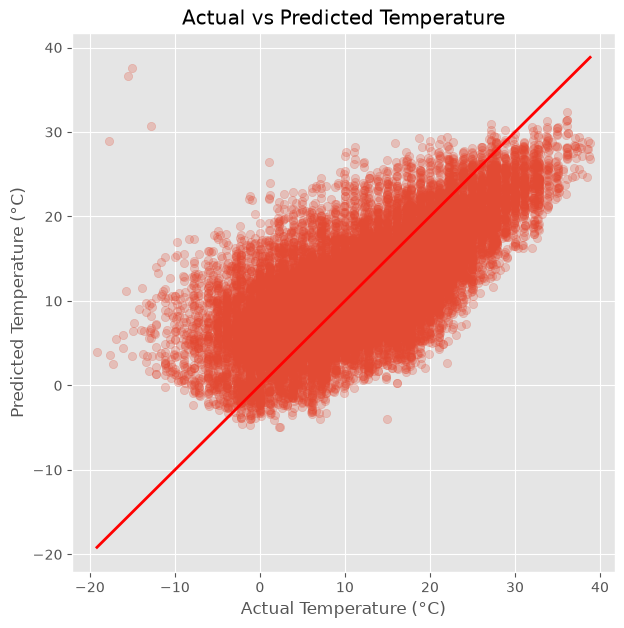

In [43]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.25
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature")

plt.show()

In [44]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients

,Feature,Coefficient
0,Humidity,-29.519330
6,Month,0.510936
3,Visibility (km),0.443354
1,Wind Speed (km/h),-0.182471
5,Year,0.060061
8,Hour,-0.024234
7,Day,0.003640
2,Wind Bearing (degrees),0.003274
4,Pressure (millibars),-0.001383


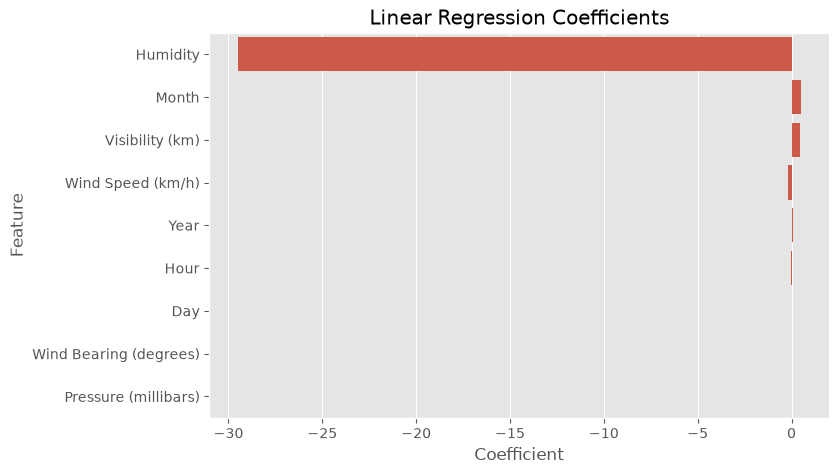

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")

plt.show()

## Model Evaluation

The Linear Regression model provides a reasonable baseline for predicting air temperature using weather-related variables.

### Key Findings

- The model achieved an **R² score of 0.48**, indicating that approximately 48% of the variability in temperature can be explained by the selected features.
- The **Mean Absolute Error (MAE)** equals **5.56°C**, meaning that predictions differ from actual temperatures by about 5–6°C on average.
- The **Root Mean Squared Error (RMSE)** of **6.92°C** suggests that larger prediction errors are present for some observations.

The scatter plot demonstrates a clear positive relationship between predicted and actual temperatures. However, the predictions are compressed toward the center of the temperature range, indicating that the linear model tends to underestimate very high temperatures and overestimate very low temperatures.

Overall, Linear Regression provides a useful baseline model, but more advanced machine learning algorithms are likely to achieve better predictive performance.

# Random Forest Regression

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Unlike Linear Regression, Random Forest is capable of capturing complex non-linear relationships between weather variables.

In [46]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [47]:
rf_pred = rf_model.predict(X_test)

In [48]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE : {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R²  : {rf_r2:.3f}")

MAE : 1.306
RMSE: 1.805
R²  : 0.965


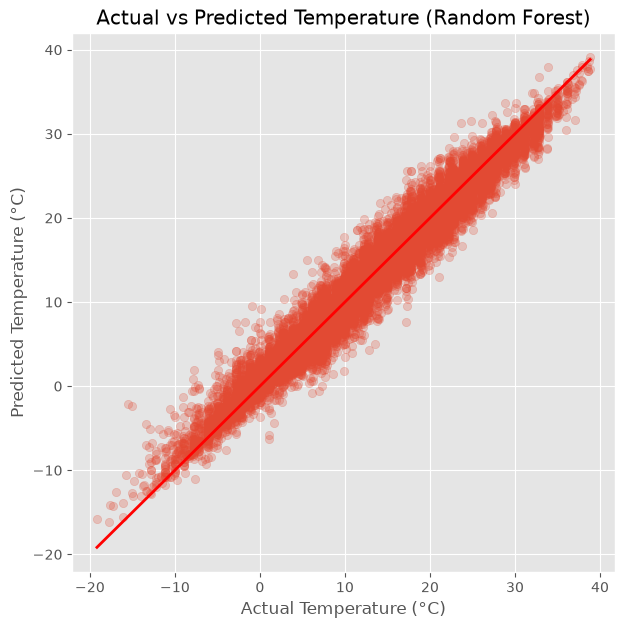

In [49]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.25
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature (Random Forest)")

plt.show()

In [50]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,Month,0.457162
0,Humidity,0.365713
4,Pressure (millibars),0.044918
7,Day,0.036842
5,Year,0.029462
8,Hour,0.020235
2,Wind Bearing (degrees),0.018777
3,Visibility (km),0.014739
1,Wind Speed (km/h),0.012152


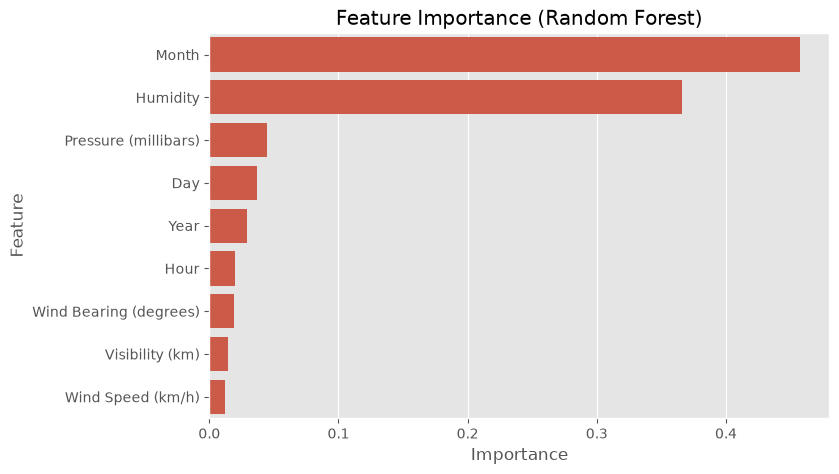

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Feature Importance

Random Forest provides an estimate of the relative importance of each predictor.

### Key Findings

- **Month** is the most influential feature, accounting for approximately **46%** of the model's predictive power. This highlights the strong seasonal nature of air temperature.
- **Humidity** is the second most important variable, contributing around **37%** of the overall importance.
- Pressure, day, year, and hour have a relatively small impact on prediction accuracy.
- Wind speed, wind bearing, and visibility contribute only marginally to the final model.

### Interpretation

The results indicate that seasonal patterns and atmospheric moisture are the primary drivers of temperature variation in this dataset. The remaining weather variables provide additional information but play a considerably smaller role in predicting air temperature.

In [52]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R²": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,5.56403,6.915892,0.481012
1,Random Forest,1.30639,1.805222,0.964639


In [53]:
comparison.style.format({
    "MAE":"{:.2f}",
    "RMSE":"{:.2f}",
    "R²":"{:.3f}"
}).highlight_max(
    subset=["R²"],
    color="lightgreen"
).highlight_min(
    subset=["MAE","RMSE"],
    color="lightgreen"
)

,Model,MAE,RMSE,R²
0,Linear Regression,5.56,6.92,0.481
1,Random Forest,1.31,1.81,0.965


## Model Comparison

Random Forest achieved substantially better predictive performance than Linear Regression.
The ensemble model reduced the prediction error by more than four degrees Celsius on average and increased the coefficient of determination from **0.48** to **0.97**. This demonstrates that weather data exhibit complex non-linear relationships that are better captured by tree-based machine learning algorithms than by a simple linear model.

# Conclusion

This project explored historical weather observations using exploratory data analysis, feature engineering, correlation analysis, and predictive modeling.
The exploratory analysis revealed that the dataset contains high-quality observations with only a small number of missing values. Temperature, humidity, pressure, wind characteristics, and visibility exhibit meaningful statistical patterns and seasonal behavior.
Correlation analysis showed that humidity is negatively associated with temperature, while apparent temperature has an almost perfect positive correlation with actual temperature. Feature engineering further improved the dataset by incorporating temporal information such as year, month, day, and hour.
Two machine learning models were developed to predict air temperature. Linear Regression provided a reasonable baseline model; however, Random Forest Regression achieved substantially better performance, reaching an **R² of approximately 0.97** while reducing both MAE and RMSE significantly.
Feature importance analysis indicated that **Month** and **Humidity** are the most influential predictors of temperature, highlighting the importance of seasonal variation and atmospheric moisture.
This project demonstrates a complete end-to-end data science workflow, including:

- Data quality assessment
- Exploratory data analysis (EDA)
- Statistical analysis
- Feature engineering
- Predictive modeling
- Model evaluation
- Interpretation of results

The workflow can be extended by testing additional machine learning algorithms such as Gradient Boosting, XGBoost, LightGBM, or Neural Networks, as well as incorporating external weather variables to further improve predictive performance.